### View FCI level 1C RRAD in netCDF (.nc) format



In [1]:
import glob
from datetime import datetime, timedelta
from satpy.scene import Scene
from satpy import find_files_and_readers

data_dir = "/Users/luciereymondet/GitHub/GOFLOW_LR/data/unzipped/1C-RRAD/"

files = find_files_and_readers(base_dir=data_dir, reader='fci_l1c_nc')

# Initialize Scene object
scn = Scene(filenames=files)
print("Available datasets:", scn.available_dataset_names()) # Prints list of available datasets
print("Available composites:", scn.available_composite_names()) # Prints list of potentially available composites

dataset = "ir_105" # Dataset to load
# note: the data inside the FCI files is stored upside down. 
# The upper_right_corner='NE' argument flips it in upright position.
scn.load([dataset], upper_right_corner='NE')

data = scn[dataset]  # daskified xarra.DataArray
data = data.data

Available datasets: ['ir_105', 'ir_105_earth_sun_distance', 'ir_105_index_map', 'ir_105_pixel_quality', 'ir_105_platform_altitude', 'ir_105_subsatellite_latitude', 'ir_105_subsatellite_longitude', 'ir_105_subsolar_latitude', 'ir_105_subsolar_longitude', 'ir_105_sun_satellite_distance', 'ir_105_swath_direction', 'ir_105_swath_number', 'ir_105_time', 'ir_123', 'ir_123_earth_sun_distance', 'ir_123_index_map', 'ir_123_pixel_quality', 'ir_123_platform_altitude', 'ir_123_subsatellite_latitude', 'ir_123_subsatellite_longitude', 'ir_123_subsolar_latitude', 'ir_123_subsolar_longitude', 'ir_123_sun_satellite_distance', 'ir_123_swath_direction', 'ir_123_swath_number', 'ir_123_time', 'ir_133', 'ir_133_earth_sun_distance', 'ir_133_index_map', 'ir_133_pixel_quality', 'ir_133_platform_altitude', 'ir_133_subsatellite_latitude', 'ir_133_subsatellite_longitude', 'ir_133_subsolar_latitude', 'ir_133_subsolar_longitude', 'ir_133_sun_satellite_distance', 'ir_133_swath_direction', 'ir_133_swath_number', 'ir_

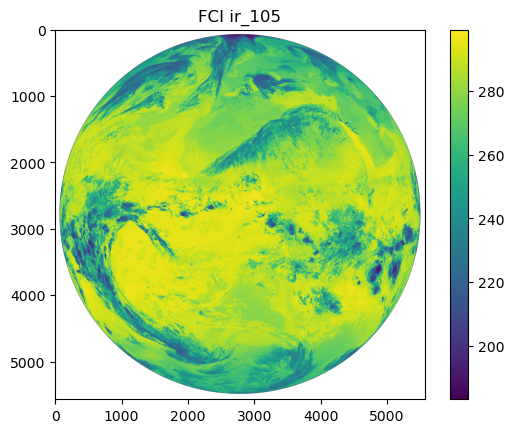

In [6]:
import matplotlib.pyplot as plt

plt.imshow(data)
plt.title(f"FCI {dataset}")
plt.colorbar()
plt.show()

In [2]:
from netCDF4 import Dataset
fci_files = files["fci_l1c_nc"]

nc = Dataset(fci_files[0])  # one of the FCI L1c files

grp = nc["data"][dataset]["measured"]

nu = grp["radiance_to_bt_conversion_coefficient_wavenumber"][:].item()
a  = grp["radiance_to_bt_conversion_coefficient_a"][:].item()
b  = grp["radiance_to_bt_conversion_coefficient_b"][:].item()
c1 = grp["radiance_to_bt_conversion_constant_c1"][:].item()
c2 = grp["radiance_to_bt_conversion_constant_c2"][:].item()

nc.close()

print(f"Conversion coefficients nu, a, b, c1, c2 for {dataset}:\n",nu, a, b , c1, c2)

Conversion coefficients nu, a, b, c1, c2 for ir_105:
 949.9734497070312 0.999032199382782 0.36442750692367554 1.1910429748240858e-05 1.4387749433517456
